# 05 · Final generative comparison (Experiment 5)
**Question:** does generation with the *correct* fMRI beat permuted / zero?

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do — this avoids a notebooks/data/... mismatch.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print('project root:', os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_config
from PIL import Image
from pathlib import Path
from src.features import load_clip
from src.evaluation import compute_generation_metrics
from src.generation import save_comparison_grid, case_grids
from src.utils import get_device, load_json
cfg = load_config('configs/exp05_generation_ablation.yaml')
device = get_device(cfg.get('runtime.device','auto'))
src_dir = Path('outputs') / cfg.get('generation.source_experiment','exp04_generation')
params = load_json(src_dir/'metadata'/'generation_params.json')
ids = params['image_ids']; conditions = [c for c in ['correct','permuted','zero'] if (src_dir/'generated'/c).exists()]
load = lambda d: [Image.open(src_dir/'generated'/d/f'{i}.png').convert('RGB') for i in ids]
outputs = {'real': load('real'), 'image_ids': ids}
for c in conditions: outputs[c] = load(c)

project root: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion


In [4]:
clip_bundle = load_clip(cfg, device)
import pandas as pd
rows, per_sample = [], {}
for c in conditions:
    r = compute_generation_metrics(
        outputs['real'],
        outputs[c],
        clip_bundle,
        device,
        use_ssim = True,
        use_lpips=True
    )
    per_sample[c] = r['per_sample']['clip_similarity']
    rows.append({'condition': c, **{k: r['metrics'][k] for k in ['mean_clip_similarity','mean_pixel_mse','mean_ssim','mean_lpips']}})
pd.DataFrame(rows)

c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


22:03:01 | INFO    | clip | Loaded open_clip ViT-L-14/openai (dim=768)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\lpips\weights\v0.1\alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\lpips\weights\v0.1\alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\lpips\weights\v0.1\alex.pth


,condition,mean_clip_similarity,mean_pixel_mse,mean_ssim,mean_lpips
0,correct,0.575655,0.080616,0.192103,0.747776
1,permuted,0.578254,0.146272,0.125882,0.791084
2,zero,0.556750,0.075541,0.220225,0.722915


## Comparison grid  [real | correct | permuted | zero]

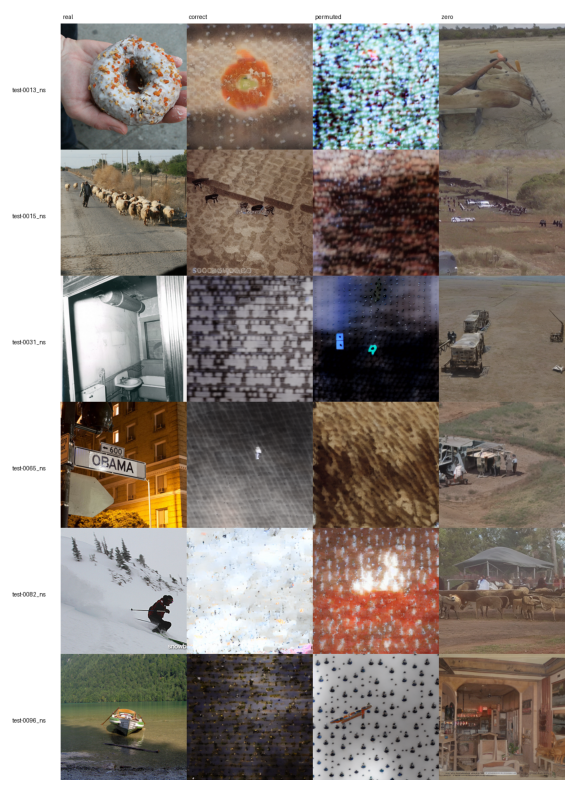

: 

In [ ]:
p = save_comparison_grid(outputs, 'exp05_grid.png',
                         column_order=('real',)+tuple(conditions), max_rows=6)
plt.figure(figsize=(12,10)); plt.imshow(Image.open(p)); plt.axis('off'); plt.show()

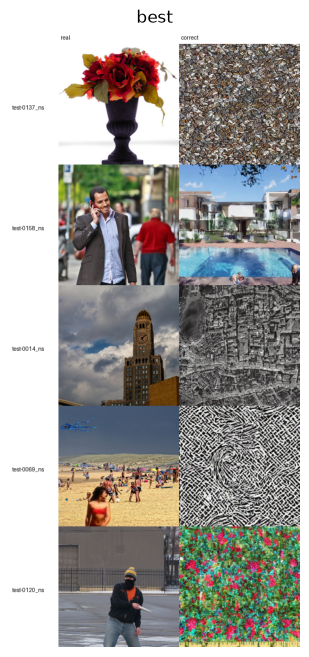

In [4]:
# best / median / worst cases ranked by correct-condition CLIP similarity
if 'correct' in per_sample:
    saved = case_grids(outputs, per_sample['correct'], '.',
                       column_order=('real',)+tuple(conditions), k=5)
    plt.figure(figsize=(12,8)); plt.imshow(Image.open(saved['best_cases'])); plt.axis('off'); plt.title('best'); plt.show()

**Conclusion:** the correct condition should show higher CLIP similarity to the real image than permuted/zero. If it does not, the generator is not making meaningful use of the fMRI signal, and this must be stated in the report.